1.Imports Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sp
from scipy.fft import fft, fftfreq
from scipy.signal import (
    welch,
    butter,
    sosfiltfilt,
    detrend,
    savgol_filter
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")


np.random.seed(42)


sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",

    "axes.titlesize": 11,
    "axes.labelsize": 10,

    "axes.spines.top": False,
    "axes.spines.right": False
})

print("All libraries imported successfully.")
print("Environment is ready for signal analysis and ML modeling.")

All libraries imported successfully.
Environment is ready for signal analysis and ML modeling.


 2.Data Loading

In [33]:
EXCEL_PATH = "READINGS.xlsx"

FS = 100.0
WINDOW_SIZE = 200
STEP_SIZE   = 100

xl = pd.read_excel(
    EXCEL_PATH,
    sheet_name=None,
    header=None
)

records = []

sid = 0

for sheet_name, df_raw in xl.items():

    bpm = int(sheet_name.split()[0])

    freq_hz = bpm / 60.0

    df_data = df_raw.iloc[2:].reset_index(drop=True)

    df_data.columns = [
        't1', 'v1',
        't2', 'v2',
        't3', 'v3'
    ]


    for set_idx, vcol in enumerate(['v1', 'v2', 'v3'], start=1):

        sig = pd.to_numeric(
            df_data[vcol],
            errors='coerce'
        ).dropna().values.astype(np.float64)


        records.append({
            'bpm'       : bpm,
            'freq_hz'   : freq_hz,
            'set_idx'   : set_idx,
            'signal_id' : sid,
            'signal'    : sig
        })


        sid += 1


bpm_groups = {}

for r in records:
    bpm_groups.setdefault(r['bpm'], []).append(r)

bpm_list = sorted(bpm_groups.keys())


print(f"\nLoaded {len(records)} signals from {len(xl)} BPM classes\n")

print(
    f"{'BPM':<8}"
    f"{'Freq(Hz)':<12}"
    f"{'Set':<6}"
    f"{'Sig ID':<10}"
    f"{'Samples':<10}"
    f"{'Duration(s)'}"
)

print("-" * 56)

for r in records:

    duration = len(r['signal']) / FS

    print(
        f"{r['bpm']:<8}"
        f"{r['freq_hz']:<12.2f}"
        f"{r['set_idx']:<6}"
        f"{r['signal_id']:<10}"
        f"{len(r['signal']):<10}"
        f"{duration:.1f}"
    )


Loaded 21 signals from 7 BPM classes

BPM     Freq(Hz)    Set   Sig ID    Samples   Duration(s)
--------------------------------------------------------
60      1.00        1     0         2001      20.0
60      1.00        2     1         2001      20.0
60      1.00        3     2         2001      20.0
120     2.00        1     3         2001      20.0
120     2.00        2     4         2001      20.0
120     2.00        3     5         2001      20.0
180     3.00        1     6         2001      20.0
180     3.00        2     7         2001      20.0
180     3.00        3     8         2001      20.0
240     4.00        1     9         2001      20.0
240     4.00        2     10        2001      20.0
240     4.00        3     11        2001      20.0
300     5.00        1     12        2001      20.0
300     5.00        2     13        2001      20.0
300     5.00        3     14        2001      20.0
360     6.00        1     15        2001      20.0
360     6.00        2     16  

3. Data Preprocessing

In [39]:
def remove_outliers(sig):


    q1, q3 = np.percentile(sig, [25, 75])

    iqr = q3 - q1

    lower = q1 - (3.0 * iqr)
    upper = q3 + (3.0 * iqr)

    cleaned_signal = sig[
        (sig >= lower) & (sig <= upper)
    ]

    return cleaned_signal


def normalize_signal(sig):
    """
    Performs Min-Max normalization.
    Output range: 0 to 1
    """

    mn = sig.min()
    mx = sig.max()


    if (mx - mn) < 1e-10:
        return sig

    normalized = (sig - mn) / (mx - mn)

    return normalized


print(
    f"{'BPM':<8}"
    f"{'Set':<6}"
    f"{'Raw N':<10}"
    f"{'After Outlier Removal':<24}"
    f"{'Raw Mean':<14}"
    f"{'Raw Std':<12}"
    f"{'Removed'}"
)

print("-" * 84)



for r in records:


    raw = r['signal']


    cleaned = remove_outliers(raw)


    r['signal_clean'] = cleaned

    removed = len(raw) - len(cleaned)


    print(
        f"{r['bpm']:<8}"
        f"{r['set_idx']:<6}"
        f"{len(raw):<10}"
        f"{len(cleaned):<24}"
        f"{raw.mean():<14.4f}"
        f"{raw.std():<12.4f}"
        f"{removed}"
    )


print("\nOutlier removal complete.")
print("Signals are now ready for preprocessing and feature extraction.")

BPM     Set   Raw N     After Outlier Removal   Raw Mean      Raw Std     Removed
------------------------------------------------------------------------------------
60      1     2001      1867                    2.2731        0.5307      134
60      2     2001      1852                    2.2720        0.5479      149
60      3     2001      1841                    2.2722        0.5592      160
120     1     2001      1779                    2.2947        0.5363      222
120     2     2001      1804                    2.2966        0.5285      197
120     3     2001      1804                    2.2958        0.5274      197
180     1     2001      1903                    2.2589        0.6329      98
180     2     2001      1921                    2.2624        0.6367      80
180     3     2001      1899                    2.2625        0.6530      102
240     1     2001      1991                    2.2587        0.6198      10
240     2     2001      1998                    2.2614  

4. Signal Processing Pipeline

In [41]:
def process_signal(sig, fs=FS):
    """
    Full preprocessing chain as per SOP:
      1. DC offset removal (subtract mean)
      2. Detrend (remove slow baseline drift)
      3. 4th-order Butterworth bandpass: 0.5–10 Hz
      4. Savitzky-Golay smoothing (window=11, poly=3)
    """
    s = sig.copy()

    # DC offset removal
    s = s - np.mean(s)

    # Detrending
    s = detrend(s)

    # Bandpass filter — 0.5–10 Hz, 4th order Butterworth
    sos = butter(4, [0.5, 10.0], btype='bandpass', fs=fs, output='sos')
    s = sosfiltfilt(sos, s)

    # Savitzky-Golay smoothing (optional step from SOP)
    s = savgol_filter(s, window_length=11, polyorder=3)

    return s


for r in records:
    r['signal_proc'] = process_signal(r['signal_clean'])

print("Signal processing complete for all 21 signals.")
print(f"\n{'BPM':<8}{'Set':<6}{'Proc Length':<14}{'Proc Mean':<16}{'Proc Std':<14}{'Proc RMS'}")
print("-" * 68)
for r in records:
    s = r['signal_proc']
    rms = np.sqrt(np.mean(s**2))
    print(f"{r['bpm']:<8}{r['set_idx']:<6}{len(s):<14}{np.mean(s):<16.6f}{np.std(s):<14.4f}{rms:.4f}")

Signal processing complete for all 21 signals.

BPM     Set   Proc Length   Proc Mean       Proc Std      Proc RMS
--------------------------------------------------------------------
60      1     1867          -0.000436       0.3357        0.3357
60      2     1852          -0.001974       0.3279        0.3279
60      3     1841          -0.002689       0.3223        0.3223
120     1     1779          -0.003733       0.2390        0.2390
120     2     1804          -0.002865       0.2559        0.2560
120     3     1804          -0.001092       0.2504        0.2504
180     1     1903          0.000146        0.4452        0.4452
180     2     1921          -0.002308       0.4651        0.4651
180     3     1899          0.000618        0.4536        0.4536
240     1     1991          -0.001507       0.4846        0.4846
240     2     1998          -0.003717       0.4985        0.4985
240     3     1992          -0.003253       0.4823        0.4823
300     1     2000          0.000933

5. Feature Extraction

In [63]:
# Feature Extraction Function

def extract_features(window, fs=FS):


    n = len(window)


    mean = np.mean(window)

    std = np.std(window, ddof=1)

    rms = np.sqrt(np.mean(window ** 2))

    energy = np.sum(window ** 2) / n



    freqs = fftfreq(n, d=1.0 / fs)


    fft_vals = np.abs(fft(window))


    pos_mask = freqs > 0

    fp = freqs[pos_mask]
    fv = fft_vals[pos_mask]


    dom_freq = fp[np.argmax(fv)]



    psd_norm = fv / (fv.sum() + 1e-12)


    sp_entropy = -np.sum(
        psd_norm * np.log2(psd_norm + 1e-12)
    )



    f_w, psd = welch(
        window,
        fs=fs,
        nperseg=min(n, 64)
    )


    psd_peak = np.max(psd)



    band = (f_w >= 3.0) & (f_w <= 7.0)

    if band.any():
        band_pwr = np.trapezoid(
            psd[band],
            f_w[band]
        )
    else:
        band_pwr = 0.0


    return {
        'mean'       : mean,
        'std'        : std,
        'rms'        : rms,
        'energy'     : energy,
        'dom_freq'   : dom_freq,
        'sp_entropy' : sp_entropy,
        'psd_peak'   : psd_peak,
        'band_power' : band_pwr,
    }


rows = []

for r in records:


    sig = r['signal_proc']

    starts = range(
        0,
        len(sig) - WINDOW_SIZE + 1,
        STEP_SIZE
    )

    for i, s in enumerate(starts):

        window = sig[s : s + WINDOW_SIZE]

        feat = extract_features(window)


        feat['signal_id'] = r['signal_id']
        feat['bpm']       = r['bpm']
        feat['win_idx']   = i

        rows.append(feat)


df = pd.DataFrame(rows)

df['label7'] = df['bpm'].map({
    60  : 0,
    120 : 1,
    180 : 2,
    240 : 3,
    300 : 4,
    360 : 5,
    420 : 6
})


df['label2'] = (df['bpm'] >= 180).astype(int)


df['class_name'] = df['bpm'].map({
    60  : '1 Hz',
    120 : '2 Hz',
    180 : '3 Hz',
    240 : '4 Hz',
    300 : '5 Hz',
    360 : '6 Hz',
    420 : '7 Hz'
})



FEAT_COLS = [
    'mean',
    'std',
    'rms',
    'energy',
    'dom_freq',
    'sp_entropy',
    'psd_peak',
    'band_power'
]



print(f"Feature matrix shape : {df.shape}")

print(f"\nSelected Features :")
print(FEAT_COLS)


print("\nClass Distribution (7-Class Problem):")

print(
    df['class_name']
    .value_counts()
    .sort_index()
)


print("\nFeature Statistics Summary:")

print(
    df[FEAT_COLS]
    .describe()
    .round(4)
)

Feature matrix shape : (378, 14)

Selected Features :
['mean', 'std', 'rms', 'energy', 'dom_freq', 'sp_entropy', 'psd_peak', 'band_power']

Class Distribution (7-Class Problem):
class_name
1 Hz    51
2 Hz    50
3 Hz    53
4 Hz    54
5 Hz    56
6 Hz    57
7 Hz    57
Name: count, dtype: int64

Feature Statistics Summary:
           mean       std       rms    energy  dom_freq  sp_entropy  psd_peak  \
count  378.0000  378.0000  378.0000  378.0000  378.0000    378.0000  378.0000   
mean    -0.0002    0.4659    0.4649    0.2323    4.7302      4.2290    0.0665   
std      0.0095    0.1278    0.1274    0.1146    1.6760      0.6217    0.0456   
min     -0.0363    0.1890    0.1885    0.0355    1.0000      2.9138    0.0041   
25%     -0.0036    0.3715    0.3712    0.1378    4.0000      3.7447    0.0263   
50%     -0.0001    0.4797    0.4785    0.2290    5.0000      4.1756    0.0506   
75%      0.0043    0.5643    0.5629    0.3169    6.0000      4.7101    0.1201   
max      0.0345    0.6911    0.

6.FFT Analysis

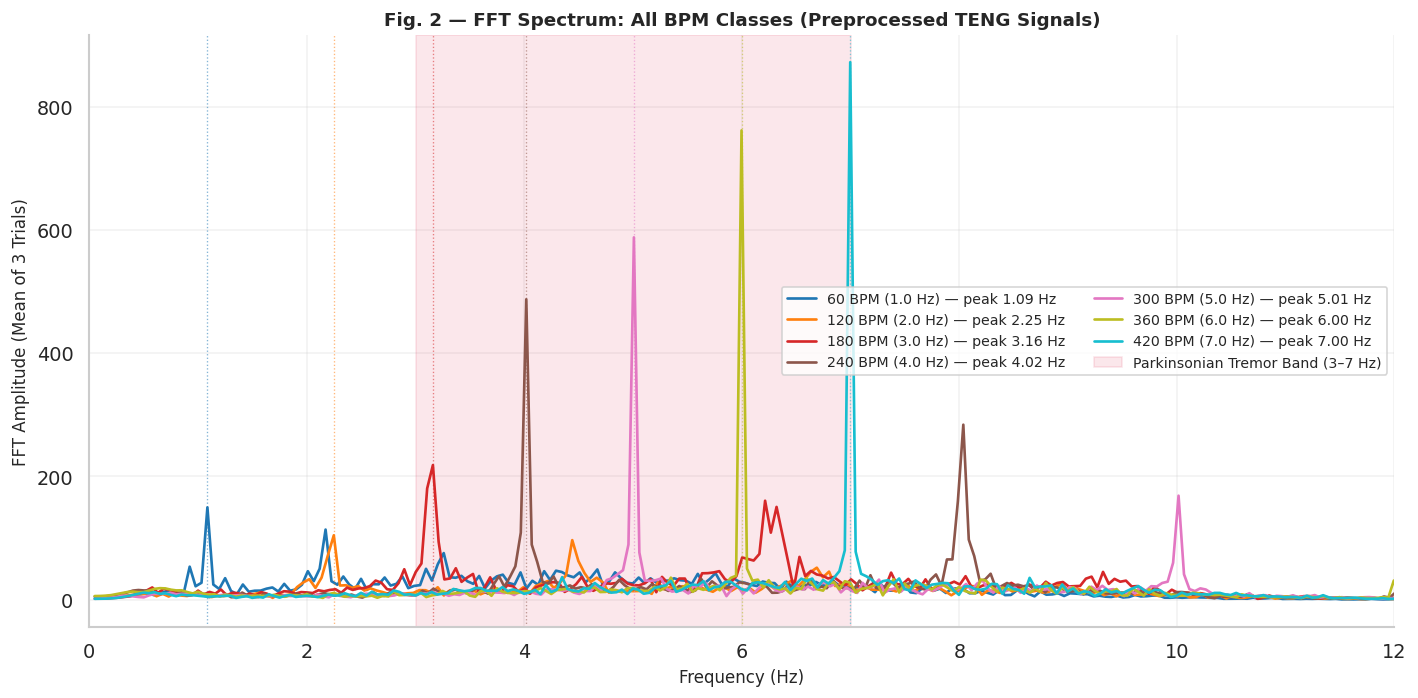

Figure 2 saved successfully.


In [49]:

def compute_fft(sig, fs=FS):
    """
    Computes FFT spectrum of the signal.
    Returns positive frequencies and amplitudes.
    """

    # total samples
    n = len(sig)

    # FFT magnitude spectrum
    fft_vals = np.abs(fft(sig))

    # frequency axis
    freqs = fftfreq(
        n,
        d=1.0 / fs
    )

    # keeping only positive frequencies
    pos = freqs > 0

    return freqs[pos], fft_vals[pos]


# Fundamental Frequency Detection


def find_fundamental(sig, fs, f_expected):
    """
    Finds dominant frequency near expected value.

    Search range:
    ±50% around expected frequency
    """

    # FFT computation
    fp, fv = compute_fft(sig, fs)

    # search limits
    lo = f_expected * 0.5
    hi = f_expected * 1.5

    # frequency mask
    mask = (fp >= lo) & (fp <= hi)

    # fallback if no frequencies found
    if not mask.any():
        return fp[np.argmax(fv)]

    # dominant peak inside selected range
    peak_freq = fp[mask][
        np.argmax(fv[mask])
    ]

    return peak_freq


# Figure 2 : FFT Spectrum for All BPM Classes


fig, ax = plt.subplots(
    figsize=(12, 6)
)

# color map for multiple classes
cmap = plt.colormaps['tab10'].resampled(
    len(bpm_list)
)


# FFT Plotting for Each BPM Class


for i, bpm in enumerate(bpm_list):

    # all trials/signals for current BPM
    recs = bpm_groups[bpm]

    # expected frequency in Hz
    freq_hz = bpm / 60.0

    # Using minimum signal length for alignment


    min_len = min(
        len(r['signal_proc'])
        for r in recs
    )

    # storing FFTs of all trials
    all_fft = []

    for r in recs:

        # trimming signal to same length
        sig_trim = r['signal_proc'][:min_len]

        # FFT computation
        _, fv_r = compute_fft(sig_trim)

        all_fft.append(fv_r)

    # reference frequency axis
    fp_ref, _ = compute_fft(
        recs[0]['signal_proc'][:min_len]
    )

    # mean FFT across trials
    mean_fft = np.mean(
        np.array(all_fft),
        axis=0
    )


    # Peak Frequency Detection


    lo = freq_hz * 0.5
    hi = freq_hz * 1.5

    mask = (fp_ref >= lo) & (fp_ref <= hi)

    if mask.any():

        peak_freq = fp_ref[mask][
            np.argmax(mean_fft[mask])
        ]

    else:
        peak_freq = fp_ref[
            np.argmax(mean_fft)
        ]


    # FFT Plot


    ax.plot(
        fp_ref,
        mean_fft,
        lw=1.6,
        color=cmap(i),
        label=(
            f'{bpm} BPM '
            f'({freq_hz:.1f} Hz) '
            f'— peak {peak_freq:.2f} Hz'
        )
    )

    # peak marker
    ax.axvline(
        peak_freq,
        color=cmap(i),
        lw=0.8,
        linestyle=':',
        alpha=0.55
    )


# Parkinsonian Tremor Frequency Band


ax.axvspan(
    3,
    7,
    alpha=0.10,
    color='crimson',
    label='Parkinsonian Tremor Band (3–7 Hz)'
)

# Figure Formatting


ax.set_xlim(0, 12)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('FFT Amplitude (Mean of 3 Trials)')

ax.set_title(
    'Fig. 2 — FFT Spectrum: All BPM Classes '
    '(Preprocessed TENG Signals)',
    fontweight='bold'
)

ax.legend(
    ncol=2,
    fontsize=8.5
)

ax.grid(alpha=0.25)

# adjusting layout
plt.tight_layout()

# saving figure
plt.savefig(
    'fig2_fft_all_classes.png',
    dpi=150,
    bbox_inches='tight'
)

# displaying plot
plt.show()

print("Figure 2 saved successfully.")

7. Heatmap and Feature Analysis

In [ ]:

# Figure 3 : Feature Analysis and Correlation Study

# creating subplot layout
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# Fig. 3a — Feature Correlation Heatmap


# correlation matrix
corr = df[FEAT_COLS].corr()

# masking upper triangle for cleaner visualization
mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

# heatmap plot
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    ax=axes[0],
    linewidths=0.4,
    annot_kws={'size': 8}
)

# subplot title
axes[0].set_title(
    'Fig. 3a — Feature Correlation Matrix',
    fontweight='bold'
)


# Fig. 3b — Mean Feature Values by BPM Class


# calculating average feature values
feat_means = (
    df.groupby('class_name')[FEAT_COLS]
    .mean()
    .T
)

# bar chart
feat_means.plot(
    kind='bar',
    ax=axes[1],
    colormap='tab10',
    edgecolor='k',
    width=0.7,
    linewidth=0.5
)

# subplot formatting
axes[1].set_title(
    'Fig. 3b — Mean Feature Values by BPM Class',
    fontweight='bold'
)

axes[1].set_ylabel('Mean Value')

axes[1].tick_params(
    axis='x',
    rotation=20
)

axes[1].legend(
    title='Class',
    fontsize=8,
    ncol=2
)

# Main Figure Title


fig.suptitle(
    'Fig. 3 — Feature Analysis (Real Dataset)',
    fontsize=13,
    fontweight='bold'
)

# adjusting spacing
plt.tight_layout()

# saving figure
plt.savefig(
    'fig3_feature_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

# displaying figure
plt.show()

print("Figure 3 saved successfully.")

8. Group-Based Train/Test Splitting



In [51]:

# Preparing Data for Machine Learning


# feature matrix
X = df[FEAT_COLS].values

# target labels (7-class classification)
# labels range from 0 to 6
y = df['label7'].values

# group labels
# used to avoid signal leakage between train/test sets
groups = df['signal_id'].values


# Stratified Group K-Fold Split


# maintains:
# 1. class balance
# 2. group separation

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# generating splits
splits = list(
    sgkf.split(X, y, groups)
)

# selecting first fold
tr_idx, te_idx = splits[0]

# Creating Train/Test Sets


X_train = X[tr_idx]
X_test  = X[te_idx]

y_train = y[tr_idx]
y_test  = y[te_idx]

# training groups
g_train = groups[tr_idx]

# Checking Signal Separation


# unique signal IDs
train_signals = sorted(
    set(groups[tr_idx])
)

test_signals = sorted(
    set(groups[te_idx])
)

# overlap detection
overlap = (
    set(groups[tr_idx]) &
    set(groups[te_idx])
)


# Split Report

print("=" * 58)
print("GROUP-BASED SPLIT REPORT")
print("=" * 58)

print(
    f"  Training windows : "
    f"{len(X_train):>5}  "
    f"signals: {train_signals}"
)

print(
    f"  Test windows     : "
    f"{len(X_test):>5}  "
    f"signals: {test_signals}"
)

print(
    f"  Signal overlap   : "
    f"{len(overlap):>5}  "
    f"← must be 0"
)

print("=" * 58)

# leakage check
if not overlap:
    print("  PASSED — zero leakage.")
else:
    print("  WARNING — leakage detected!")

# Class Distribution


print(
    f"\n  Train class dist: "
    f"{dict(zip(*np.unique(y_train, return_counts=True)))}"
)

print(
    f"  Test  class dist: "
    f"{dict(zip(*np.unique(y_test, return_counts=True)))}"
)

GROUP-BASED SPLIT REPORT
  Training windows :   305  signals: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(18), np.int64(19), np.int64(20)]
  Test windows     :    73  signals: [np.int64(1), np.int64(11), np.int64(15), np.int64(17)]
  Signal overlap   :     0  ← must be 0
  PASSED — zero leakage.

  Train class dist: {np.int64(0): np.int64(34), np.int64(1): np.int64(50), np.int64(2): np.int64(53), np.int64(3): np.int64(36), np.int64(4): np.int64(56), np.int64(5): np.int64(19), np.int64(6): np.int64(57)}
  Test  class dist: {np.int64(0): np.int64(17), np.int64(3): np.int64(18), np.int64(5): np.int64(38)}


9.Results

In [52]:

# Machine Learning Pipelines


pipelines = {

    # K-Nearest Neighbors Classifier


    'KNN': Pipeline([

        # feature normalization
        ('scaler', StandardScaler()),

        # classifier
        ('clf', KNeighborsClassifier(
            n_neighbors=5,
            metric='euclidean'
        ))
    ]),


    # Support Vector Machine Classifier


    'SVM': Pipeline([

        # feature normalization
        ('scaler', StandardScaler()),

        # classifier
        ('clf', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=42
        ))
    ]),

    # Random Forest Classifier


    'RF': Pipeline([

        # feature normalization
        ('scaler', StandardScaler()),

        # classifier
        ('clf', RandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

# Result Storage Dictionaries


cv_res = {}
test_res = {}


# Training and Evaluation Loop


for name, pipe in pipelines.items():


    # Cross-Validation Metrics

    cv_accs  = []
    cv_f1s   = []
    cv_precs = []
    cv_recs  = []

    # 5-fold group cross-validation
    for fold_tr, fold_te in sgkf.split(
        X_train,
        y_train,
        g_train
    ):

        # training model
        pipe.fit(
            X_train[fold_tr],
            y_train[fold_tr]
        )

        # validation prediction
        yp_cv = pipe.predict(
            X_train[fold_te]
        )

        # storing CV metrics
        cv_accs.append(
            accuracy_score(
                y_train[fold_te],
                yp_cv
            )
        )

        cv_f1s.append(
            f1_score(
                y_train[fold_te],
                yp_cv,
                average='weighted',
                zero_division=0
            )
        )

        cv_precs.append(
            precision_score(
                y_train[fold_te],
                yp_cv,
                average='weighted',
                zero_division=0
            )
        )

        cv_recs.append(
            recall_score(
                y_train[fold_te],
                yp_cv,
                average='weighted',
                zero_division=0
            )
        )

    # Average Cross-Validation Results


    cv_res[name] = {

        'acc'  : np.mean(cv_accs)  * 100,
        'std'  : np.std(cv_accs)   * 100,

        'f1'   : np.mean(cv_f1s)   * 100,

        'prec' : np.mean(cv_precs) * 100,
        'rec'  : np.mean(cv_recs)  * 100,
    }

    # Final Training on Full Training Set


    pipe.fit(X_train, y_train)

    # predictions
    y_pred = pipe.predict(X_test)

    # prediction probabilities
    y_prob = pipe.predict_proba(X_test)

    # Multi-Class ROC-AUC Calculation


    # converting labels into binary format
    y_te_bin = label_binarize(
        y_test,
        classes=list(range(7))
    )

    try:

        auc_val = roc_auc_score(
            y_te_bin,
            y_prob,
            multi_class='ovr',
            average='weighted'
        ) * 100

    except Exception:

        auc_val = 0.0

    # Test Results Storage


    test_res[name] = {

        'acc'  : accuracy_score(
            y_test,
            y_pred
        ) * 100,

        'prec' : precision_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ) * 100,

        'rec'  : recall_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ) * 100,

        'f1'   : f1_score(
            y_test,
            y_pred,
            average='weighted',
            zero_division=0
        ) * 100,

        'auc'  : auc_val,

        # storing predictions
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

    # Performance Report


    print(f"\n{'─' * 50}")

    print(f"  Model : {name}")

    print(
        f"  CV Accuracy : "
        f"{cv_res[name]['acc']:.2f}% "
        f"± {cv_res[name]['std']:.2f}%"
    )

    print(
        f"  CV F1 Score : "
        f"{cv_res[name]['f1']:.2f}%"
    )

    print(
        f"  Test Accuracy : "
        f"{test_res[name]['acc']:.2f}%"
    )

    print(
        f"  Test F1 Score : "
        f"{test_res[name]['f1']:.2f}%"
    )

    print(
        f"  Test ROC-AUC : "
        f"{test_res[name]['auc']:.2f}%"
    )


──────────────────────────────────────────────────
  Model : KNN
  CV Accuracy : 80.83% ± 16.77%
  CV F1 Score : 80.90%
  Test Accuracy : 91.78%
  Test F1 Score : 95.50%
  Test ROC-AUC : 100.00%

──────────────────────────────────────────────────
  Model : SVM
  CV Accuracy : 85.14% ± 13.09%
  CV F1 Score : 84.37%
  Test Accuracy : 91.78%
  Test F1 Score : 95.50%
  Test ROC-AUC : 99.80%

──────────────────────────────────────────────────
  Model : RF
  CV Accuracy : 80.68% ± 14.88%
  CV F1 Score : 82.07%
  Test Accuracy : 97.26%
  Test F1 Score : 98.59%
  Test ROC-AUC : 100.00%


10 Confusion Matrices



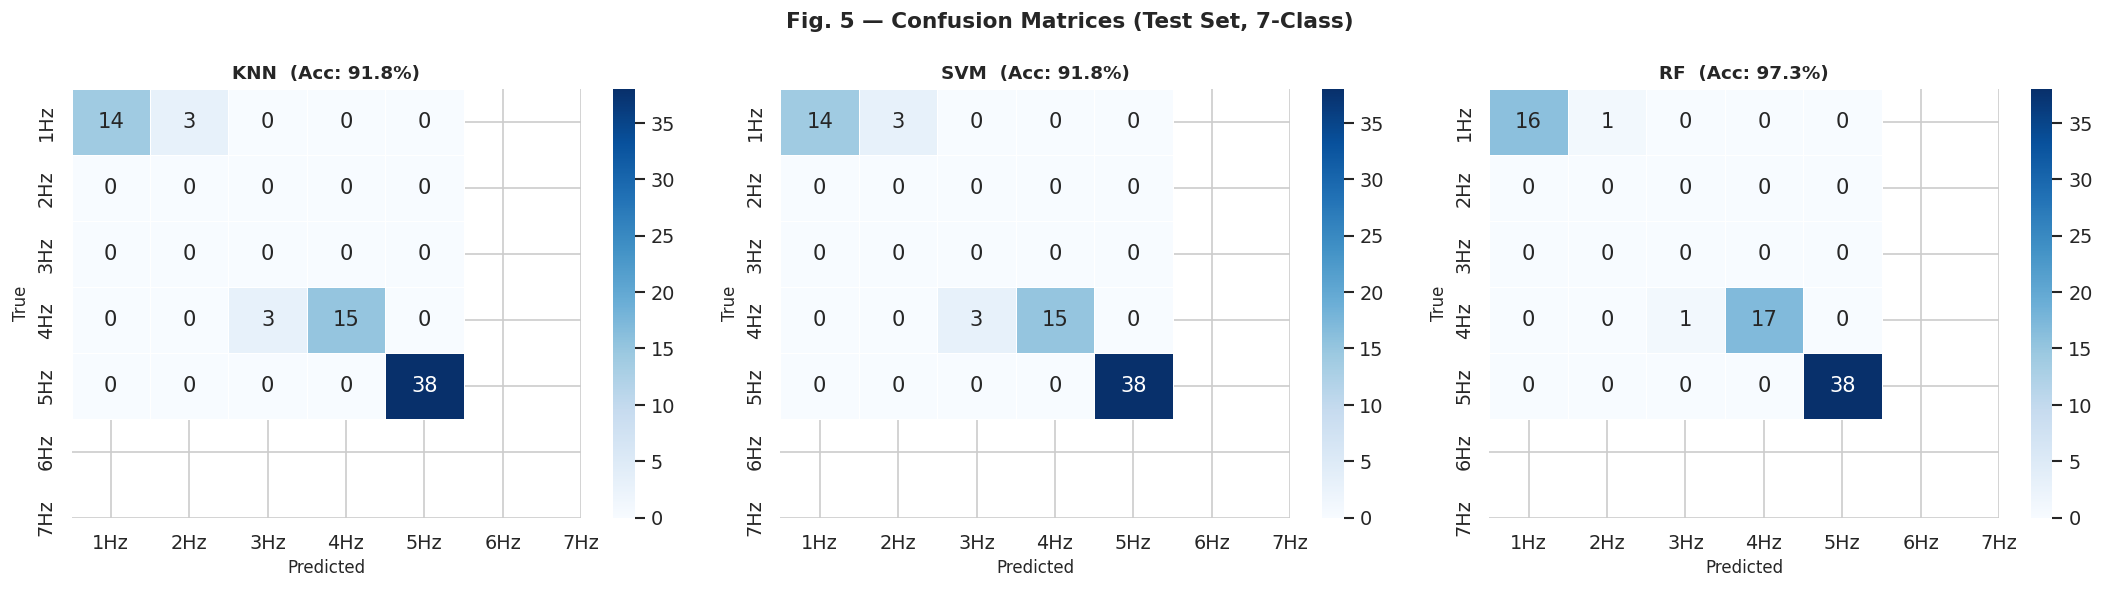

Figure 5 saved successfully.


In [53]:

# Figure 5 : Confusion Matrices for All Models


# class labels for display
class_labels = [
    '1Hz',
    '2Hz',
    '3Hz',
    '4Hz',
    '5Hz',
    '6Hz',
    '7Hz'
]

# creating subplot layout
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Plotting Confusion Matrix for Each Model


for ax, (name, res) in zip(
    axes,
    test_res.items()
):

    # confusion matrix
    cm = confusion_matrix(
        y_test,
        res['y_pred']
    )

    # heatmap visualization
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',

        xticklabels=class_labels,
        yticklabels=class_labels,

        ax=ax,
        linewidths=0.4,
        cbar=True
    )

    # subplot title
    ax.set_title(
        f"{name}  "
        f"(Acc: {res['acc']:.1f}%)",
        fontweight='bold'
    )

    # axis labels
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')


# Main Figure Title

fig.suptitle(
    'Fig. 5 — Confusion Matrices '
    '(Test Set, 7-Class)',
    fontsize=13,
    fontweight='bold'
)

# adjusting spacing
plt.tight_layout()

# saving figure
plt.savefig(
    'fig5_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)

# displaying figure
plt.show()

print("Figure 5 saved successfully.")

11. Model Comparison Graph

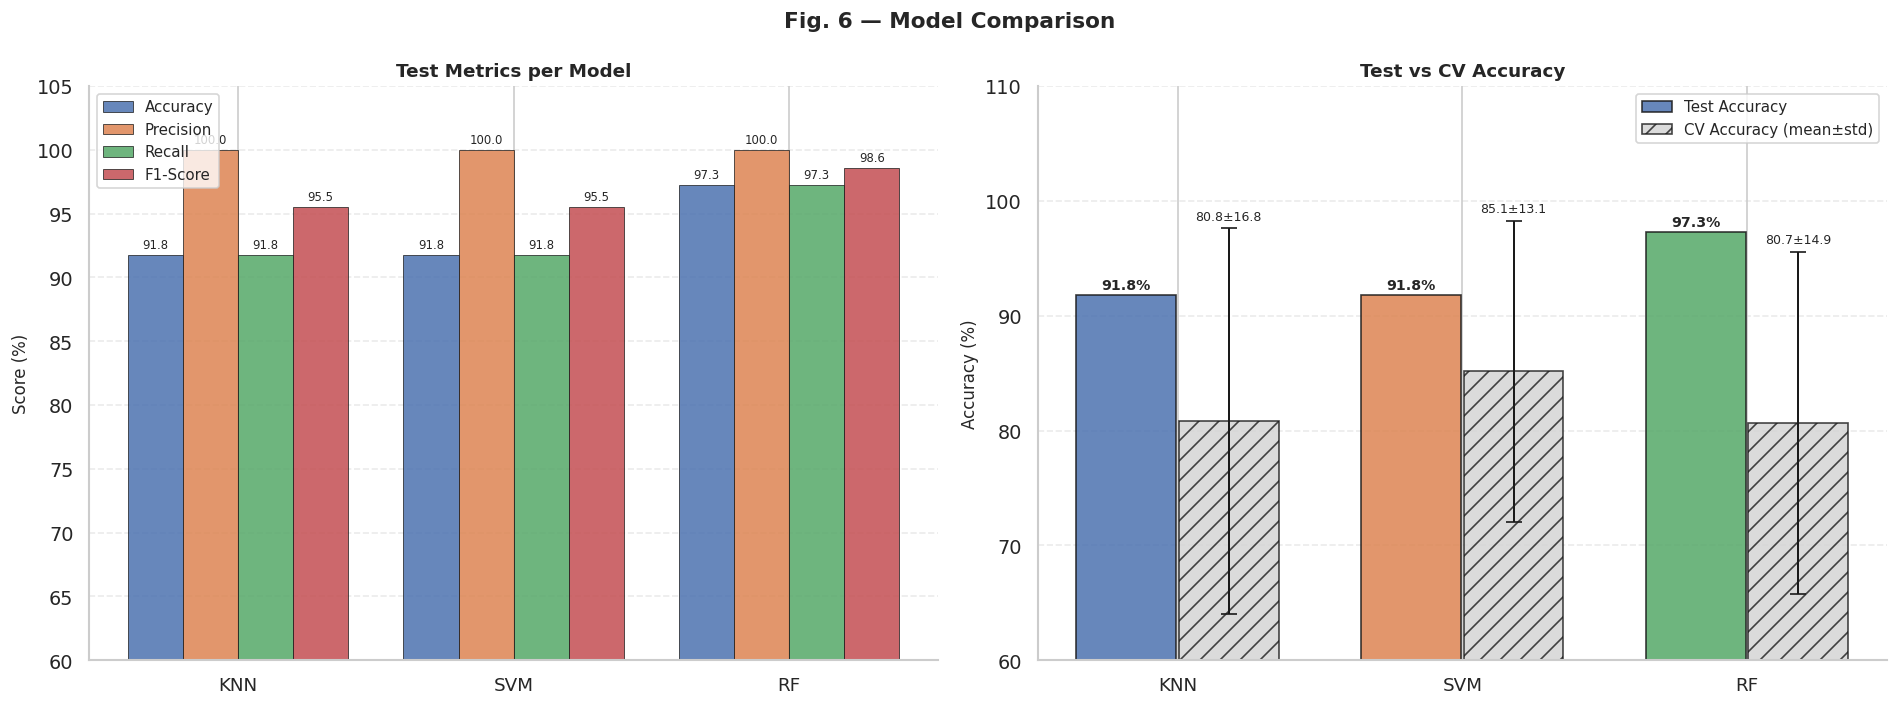

Fig. 6 saved.


In [59]:
model_names = list(pipelines.keys())
metrics_plot = ['acc', 'prec', 'rec', 'f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x     = np.arange(len(model_names))
width = 0.2
colors_bar = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: grouped bar for all 4 metrics ──
ax = axes[0]
for j, (m, lbl) in enumerate(zip(metrics_plot, metric_names)):
    vals = [test_res[nm][m] for nm in model_names]
    bars = ax.bar(x + j * width - 1.5 * width, vals, width,
                  label=lbl, color=colors_bar[j], edgecolor='k',
                  alpha=0.85, linewidth=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 105)
ax.set_title('Test Metrics per Model', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Right: CV vs Test accuracy with error bars ──
ax2 = axes[1]
test_accs = [test_res[nm]['acc']  for nm in model_names]
cv_means  = [cv_res[nm]['acc']    for nm in model_names]
cv_stds   = [cv_res[nm]['std']    for nm in model_names]
model_colors = {'KNN':'#4C72B0','SVM':'#DD8452','RF':'#55A868'}

b1 = ax2.bar(x - 0.18, test_accs, 0.35,
             color=[model_colors[n] for n in model_names],
             edgecolor='k', alpha=0.85, label='Test Accuracy')
b2 = ax2.bar(x + 0.18, cv_means, 0.35,
             color='lightgray', edgecolor='k', alpha=0.8, hatch='//',
             label='CV Accuracy (mean±std)',
             yerr=cv_stds, capsize=5, error_kw={'lw':1.2})

for b, v in zip(b1, test_accs):
    ax2.text(b.get_x() + b.get_width()/2, v+0.3, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for b, v, s in zip(b2, cv_means, cv_stds):
    ax2.text(b.get_x() + b.get_width()/2, v+s+0.5, f'{v:.1f}±{s:.1f}',
             ha='center', va='bottom', fontsize=7.5)

ax2.set_xticks(x); ax2.set_xticklabels(model_names, fontsize=11)
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(60, 110)
ax2.set_title('Test vs CV Accuracy', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

fig.suptitle('Fig. 6 — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig. 6 saved.')

12.ROC Curves

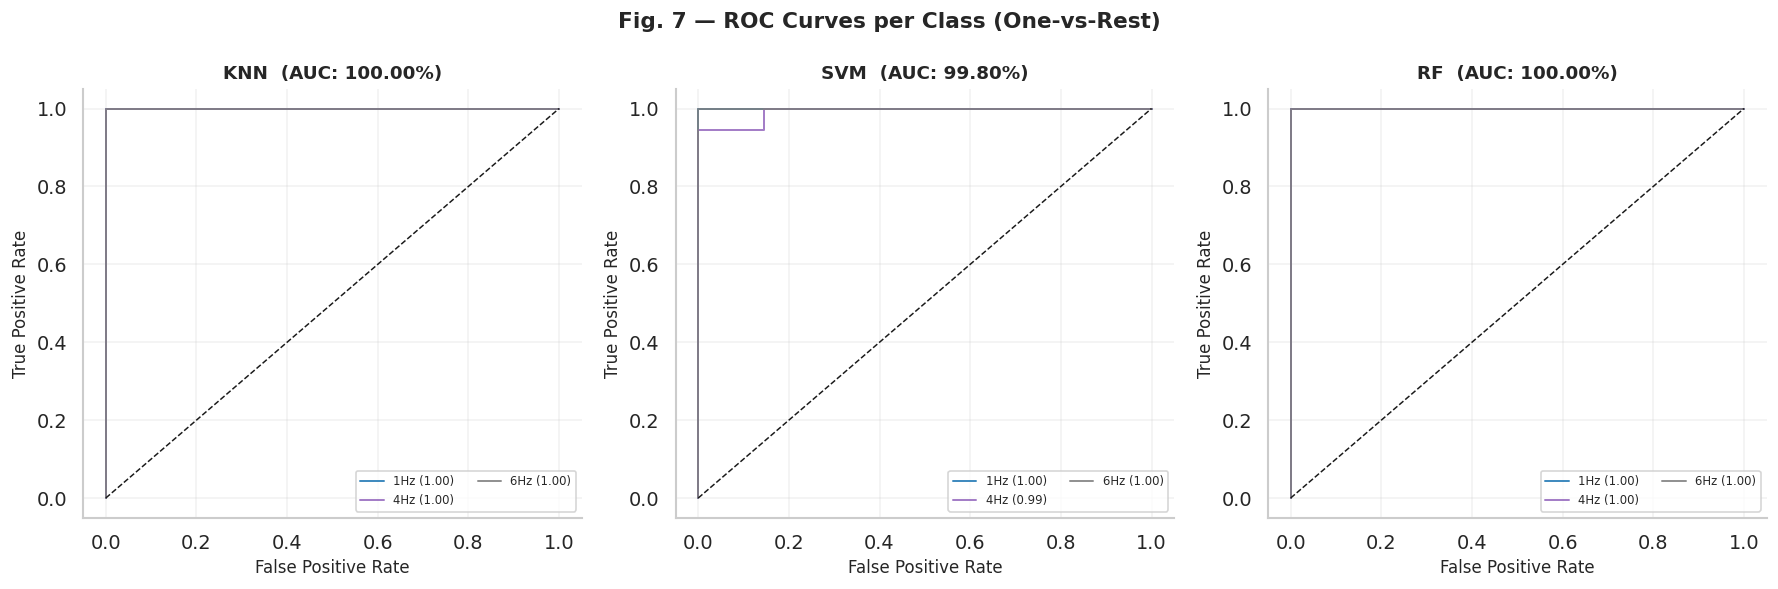

Figure 7 saved successfully.


In [60]:

# Figure 7 : Multi-Class ROC Curve Analysis


# creating subplot layout
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# color map for all 7 classes
roc_colors_cls = plt.colormaps['tab10'](
    np.linspace(0, 0.9, 7)
)


# Plotting ROC Curves for Each Model


for ax, (name, res) in zip(
    axes,
    test_res.items()
):

    # converting labels into binary format
    y_te_bin = label_binarize(
        y_test,
        classes=list(range(7))
    )

    # predicted probabilities
    y_prob = res['y_prob']


    # ROC Curve for Each Class


    for cls_i in range(7):

        # skipping missing classes
        if y_te_bin[:, cls_i].sum() == 0:
            continue

        # ROC computation
        fpr, tpr, _ = roc_curve(
            y_te_bin[:, cls_i],
            y_prob[:, cls_i]
        )

        # area under curve
        roc_auc_val = auc(fpr, tpr)

        # ROC plot
        ax.plot(
            fpr,
            tpr,

            lw=1.2,

            color=roc_colors_cls[cls_i],

            label=(
                f'{class_labels[cls_i]} '
                f'({roc_auc_val:.2f})'
            ),

            alpha=0.85
        )

    # Random Guess Reference Line


    ax.plot(
        [0, 1],
        [0, 1],
        'k--',
        lw=0.9
    )


    # Axis Formatting


    ax.set_title(
        f'{name}  '
        f'(AUC: {res["auc"]:.2f}%)',
        fontweight='bold'
    )

    ax.set_xlabel('False Positive Rate')

    ax.set_ylabel('True Positive Rate')

    ax.legend(
        fontsize=7,
        ncol=2
    )

    ax.grid(alpha=0.25)

# Main Figure Title


fig.suptitle(
    'Fig. 7 — ROC Curves per Class '
    '(One-vs-Rest)',
    fontsize=13,
    fontweight='bold'
)

# adjusting layout
plt.tight_layout()

# saving figure
plt.savefig(
    'fig7_roc_curves.png',
    dpi=150,
    bbox_inches='tight'
)

# displaying figure
plt.show()

print("Figure 7 saved successfully.")

13.Random Forest Feature Importance

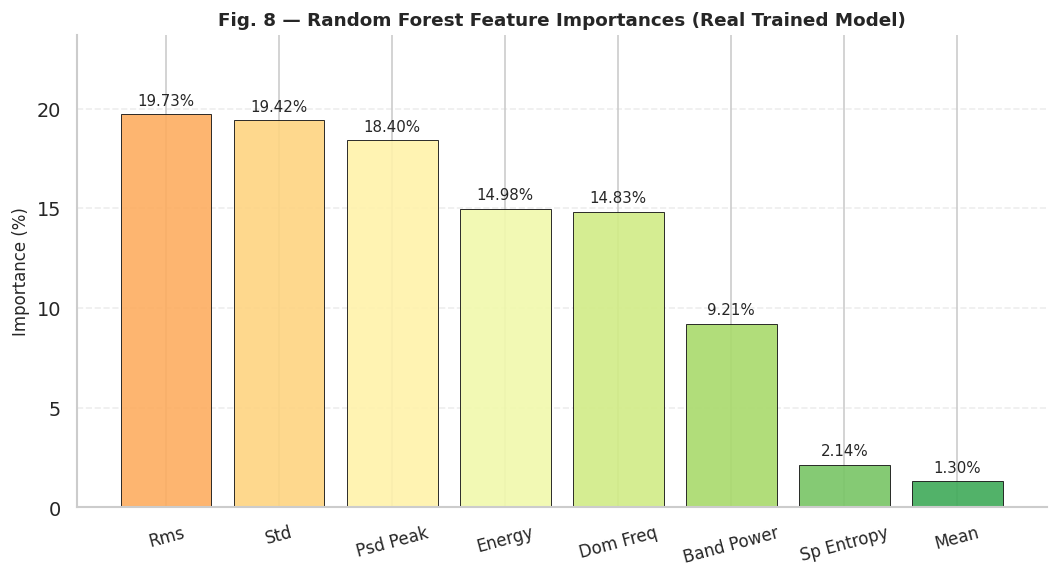

Figure 8 saved successfully.


In [16]:

# Figure 8 : Random Forest Feature Importance Analysis


# extracting feature importance values
importances = (
    pipelines['RF']
    .named_steps['clf']
    .feature_importances_
) * 100

# sorting features by importance (descending order)
sorted_idx = np.argsort(
    importances
)[::-1]

# formatted feature names
feat_labels = [
    FEAT_COLS[i]
    .replace('_', ' ')
    .title()

    for i in sorted_idx
]


# Creating Figure

fig, ax = plt.subplots(
    figsize=(9, 5)
)

# custom color map
bar_colors = plt.colormaps['RdYlGn'](
    np.linspace(
        0.3,
        0.85,
        len(FEAT_COLS)
    )
)


# Bar Plot


bars = ax.bar(
    range(len(FEAT_COLS)),

    importances[sorted_idx],

    color=bar_colors,

    edgecolor='k',
    alpha=0.9,
    linewidth=0.6
)


# Axis Formatting


ax.set_xticks(
    range(len(FEAT_COLS))
)

ax.set_xticklabels(
    feat_labels,
    fontsize=10,
    rotation=15
)

ax.set_ylabel('Importance (%)')

ax.set_title(
    'Fig. 8 — Random Forest Feature Importances '
    '(Real Trained Model)',
    fontweight='bold'
)

# y-axis limit
ax.set_ylim(
    0,
    max(importances) * 1.2
)

# Value Labels on Bars


for b, imp in zip(
    bars,
    importances[sorted_idx]
):

    ax.text(
        b.get_x() + b.get_width() / 2,
        imp + 0.3,

        f'{imp:.2f}%',

        ha='center',
        va='bottom',

        fontsize=9
    )

# Grid Styling


ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

# adjusting layout
plt.tight_layout()

# saving figure
plt.savefig(
    'fig8_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

# displaying figure
plt.show()

print("Figure 8 saved successfully.")

14. Spectral Analysis


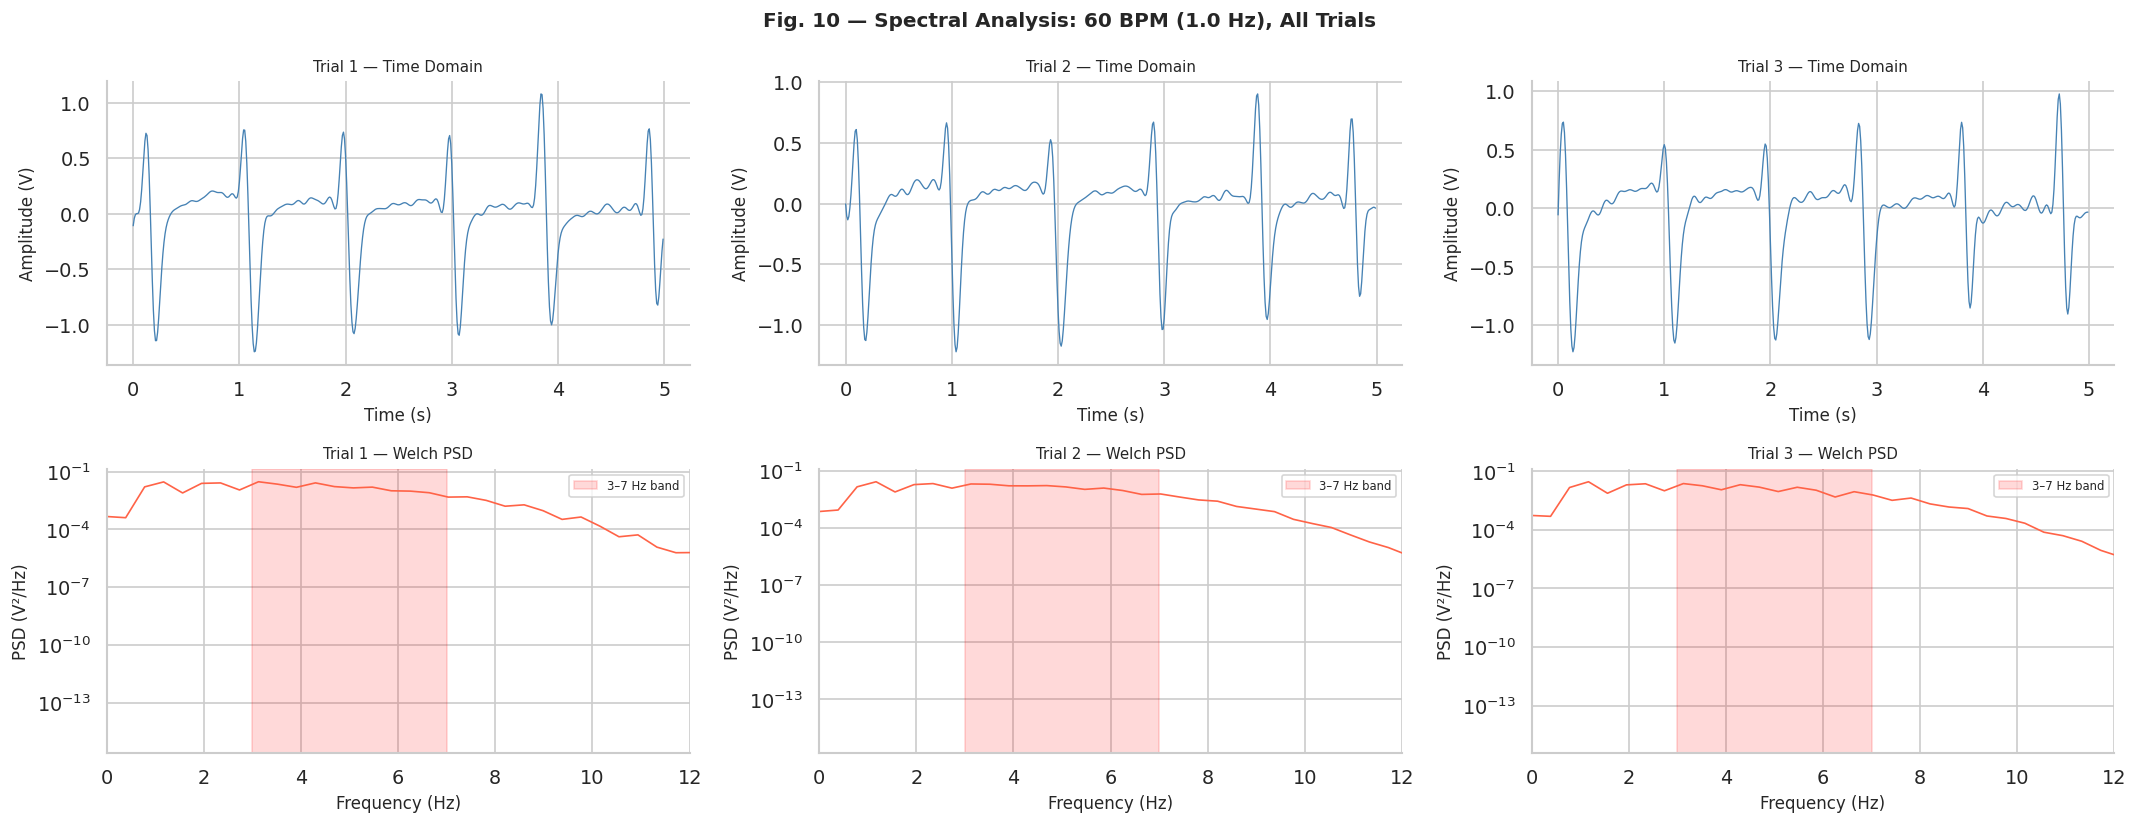

Spectral analysis figure saved for 60 BPM.


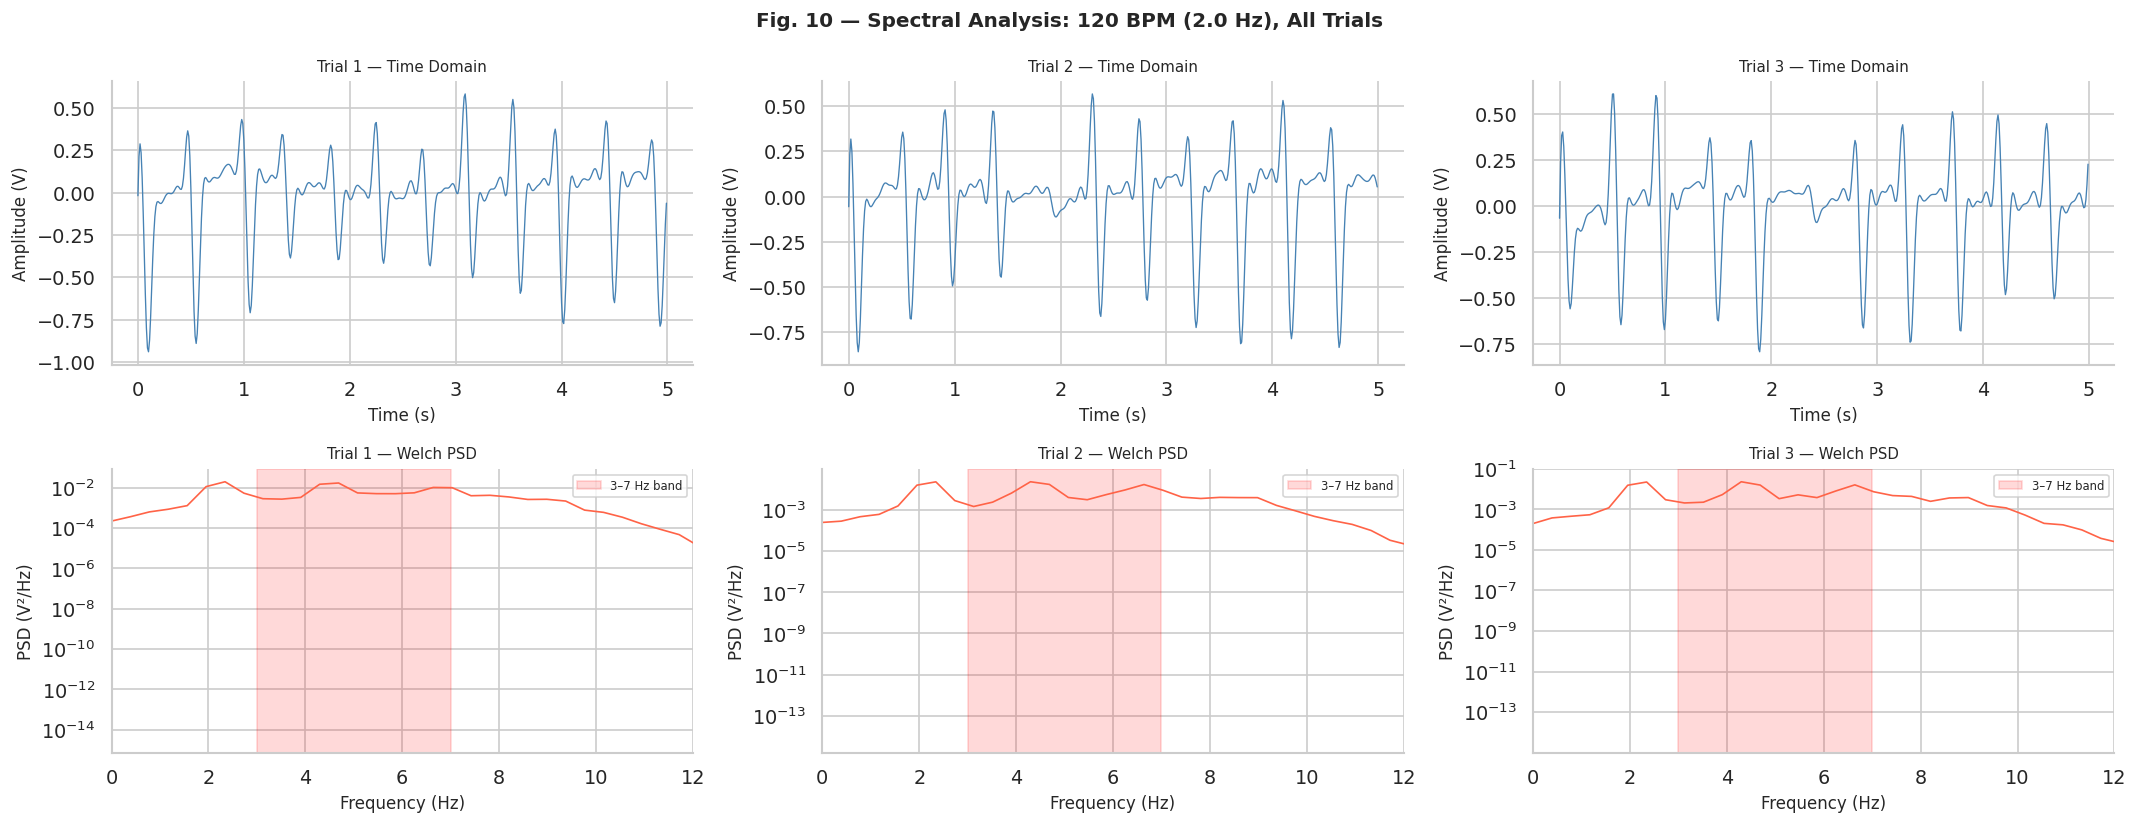

Spectral analysis figure saved for 120 BPM.


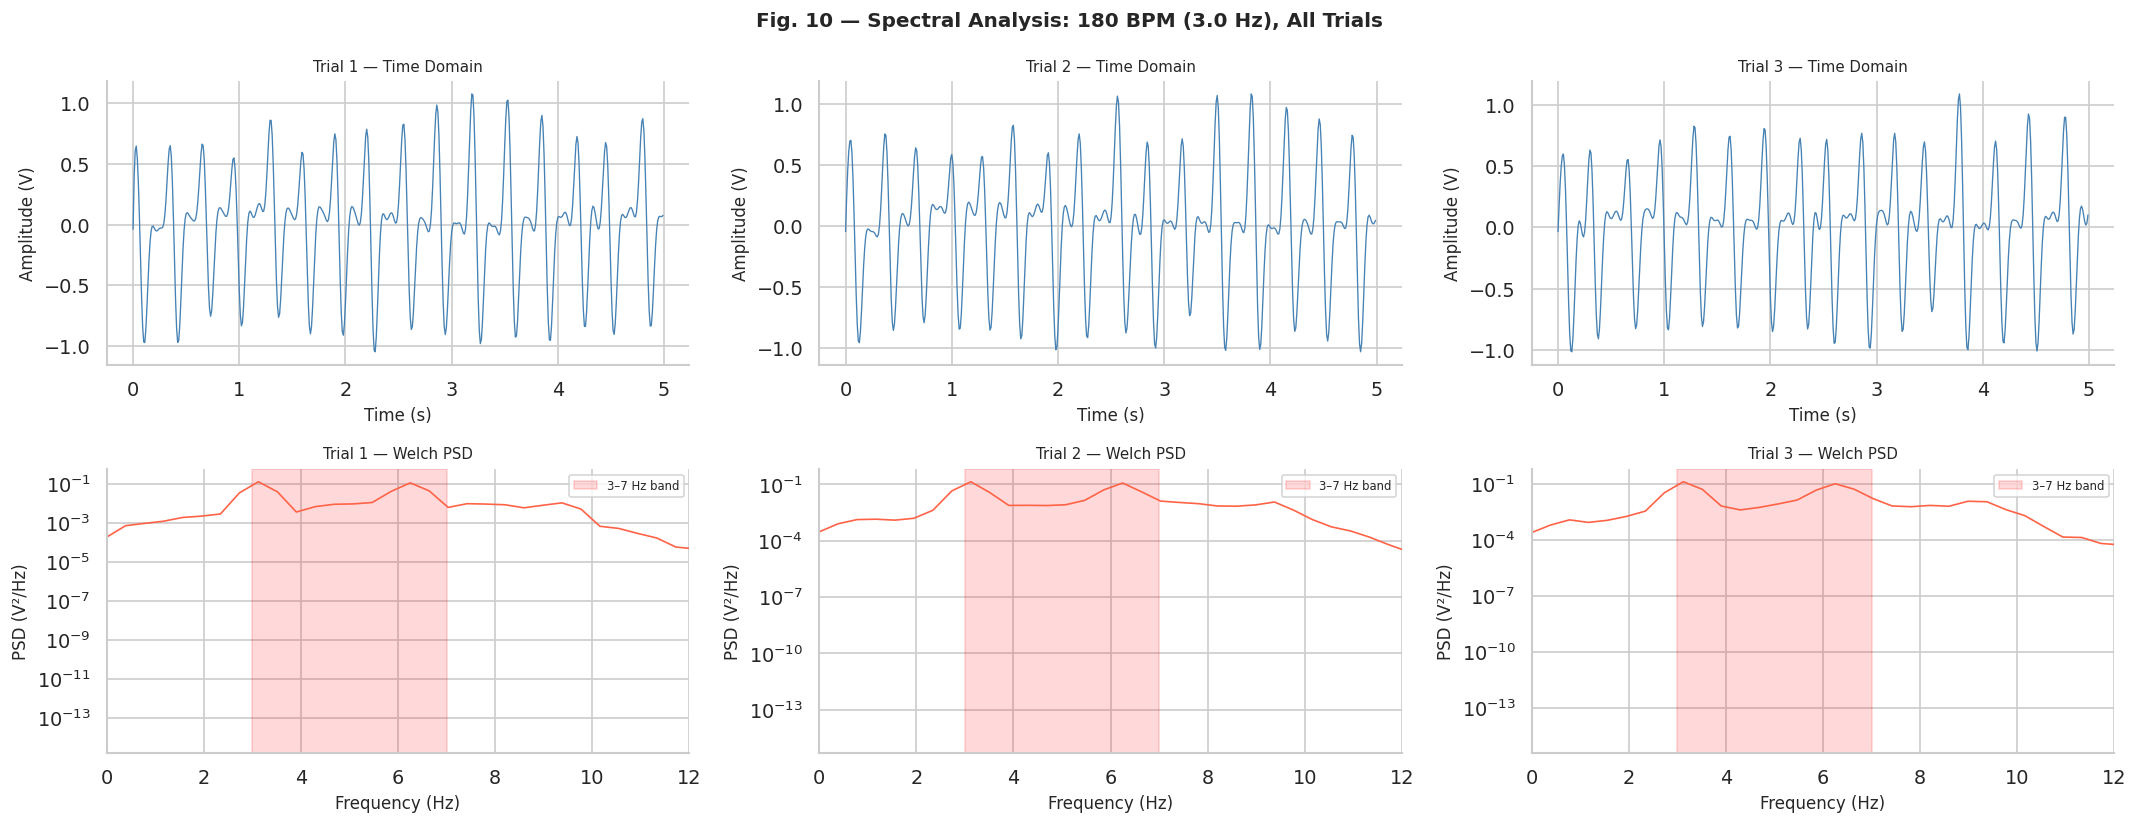

Spectral analysis figure saved for 180 BPM.


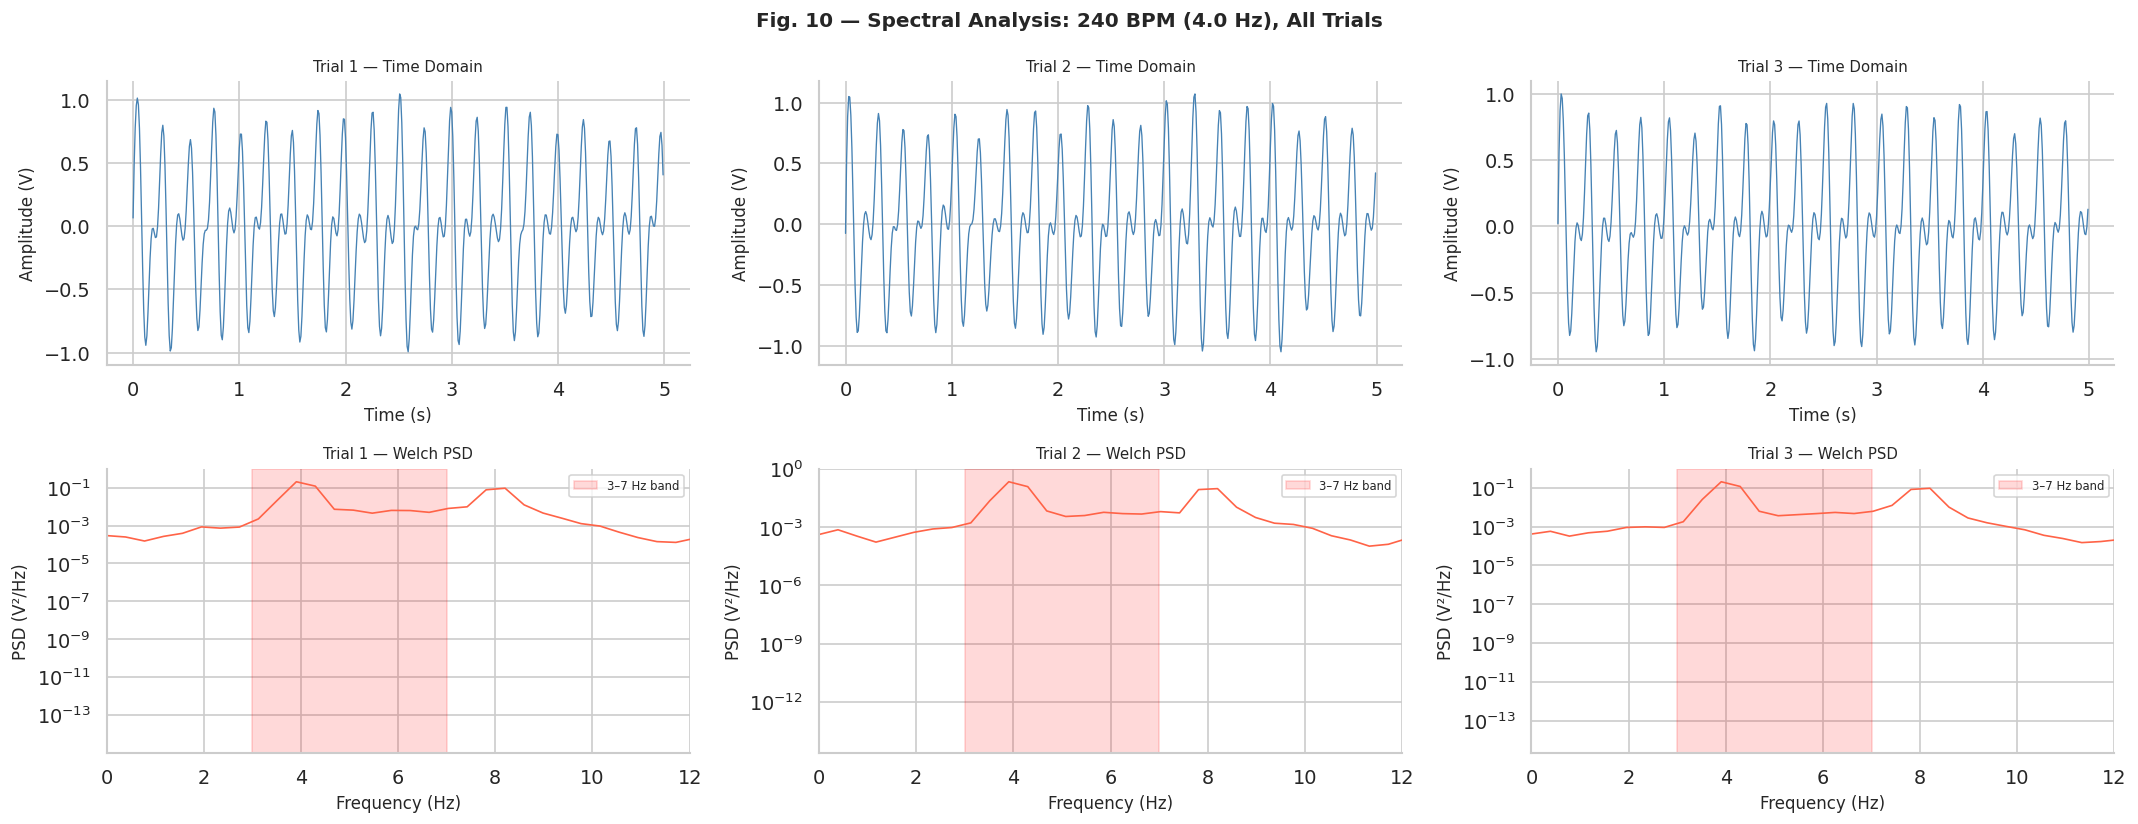

Spectral analysis figure saved for 240 BPM.


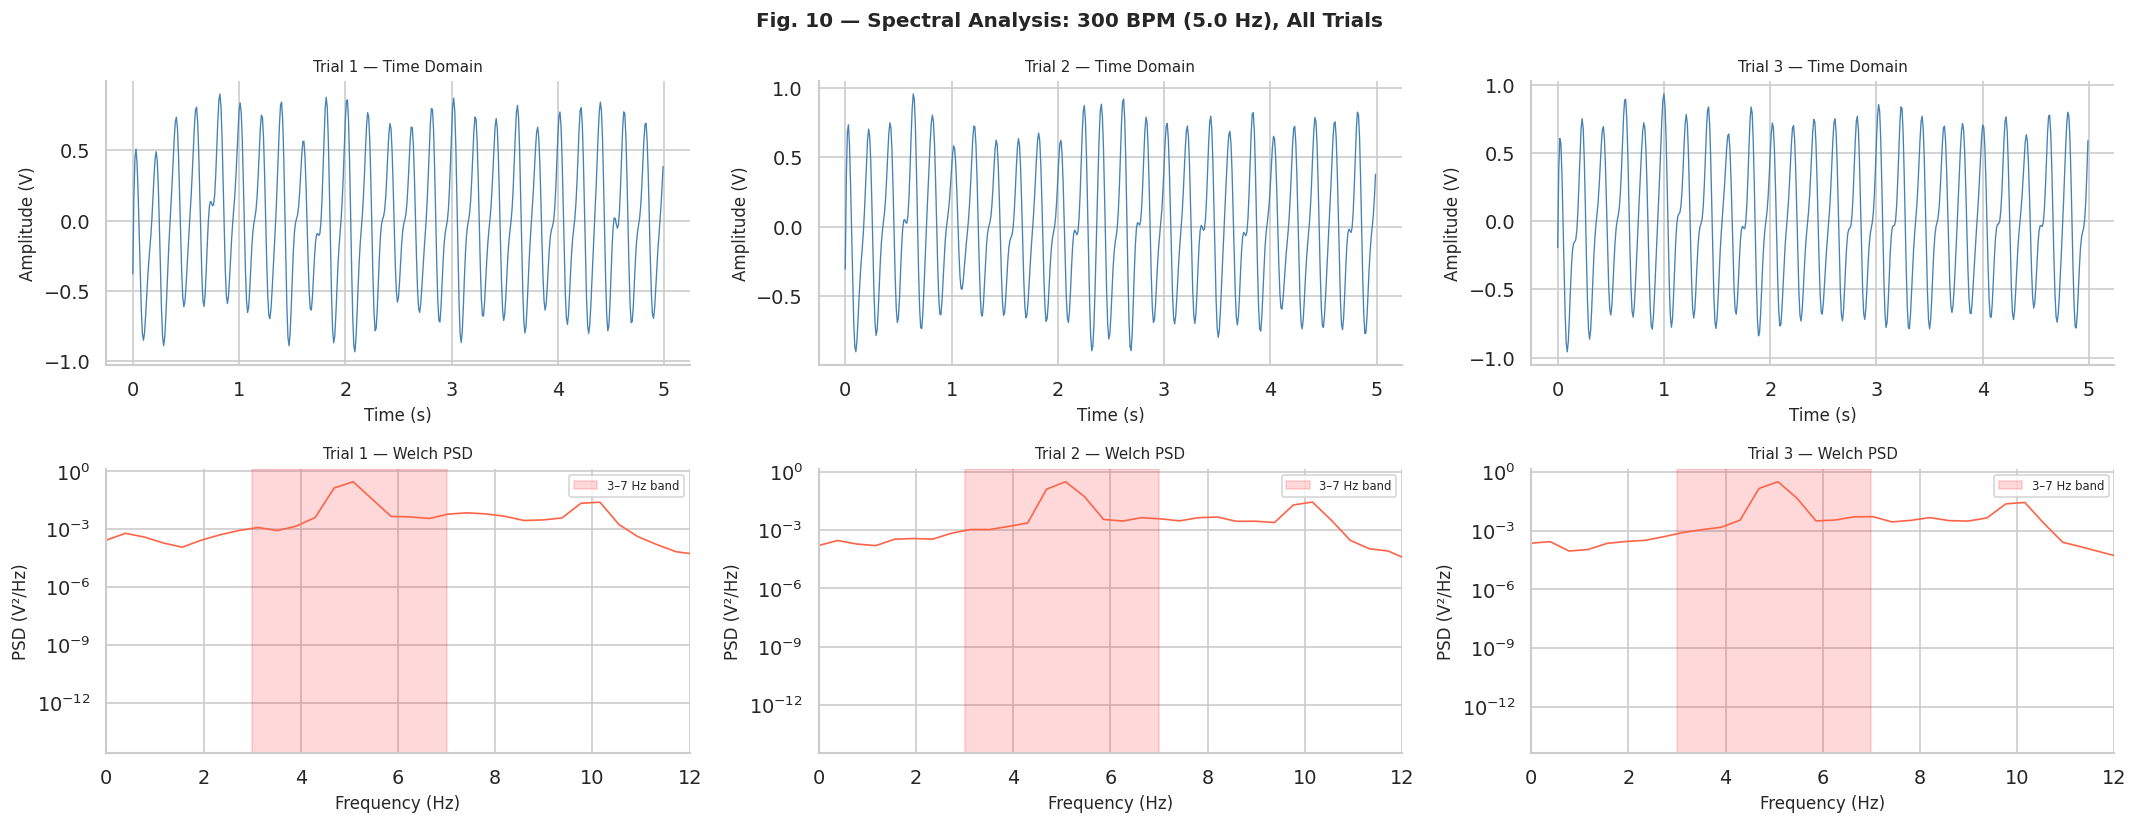

Spectral analysis figure saved for 300 BPM.


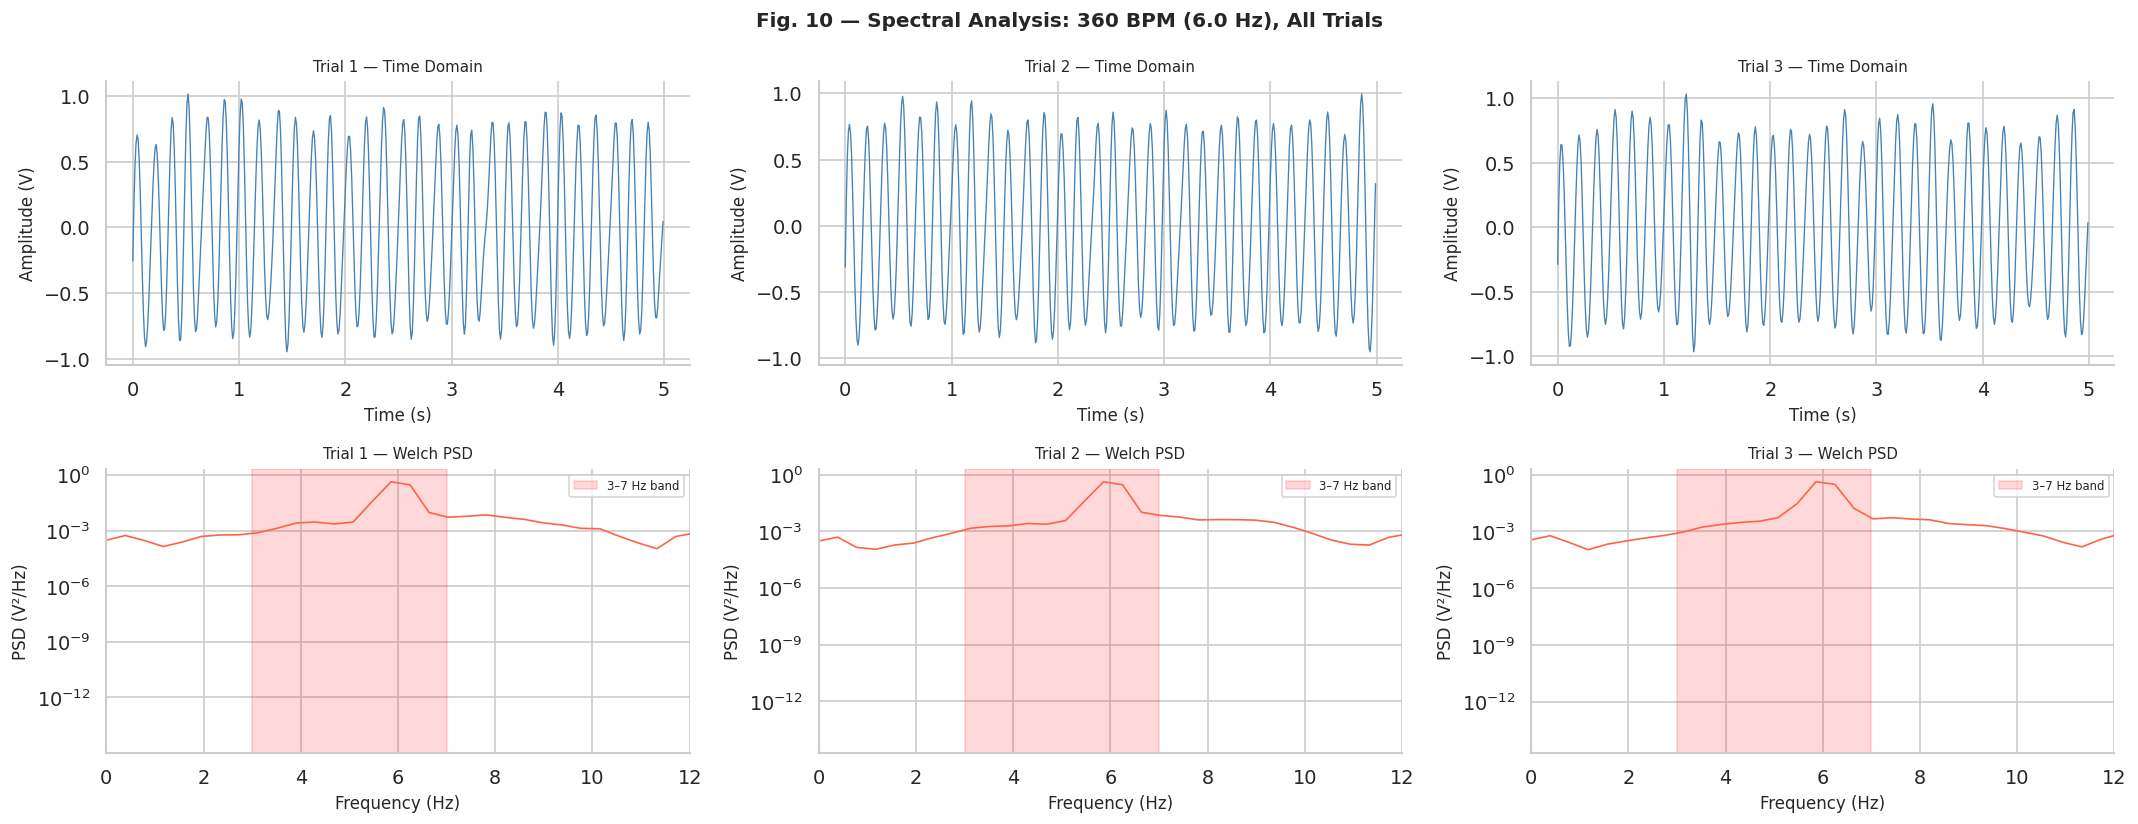

Spectral analysis figure saved for 360 BPM.


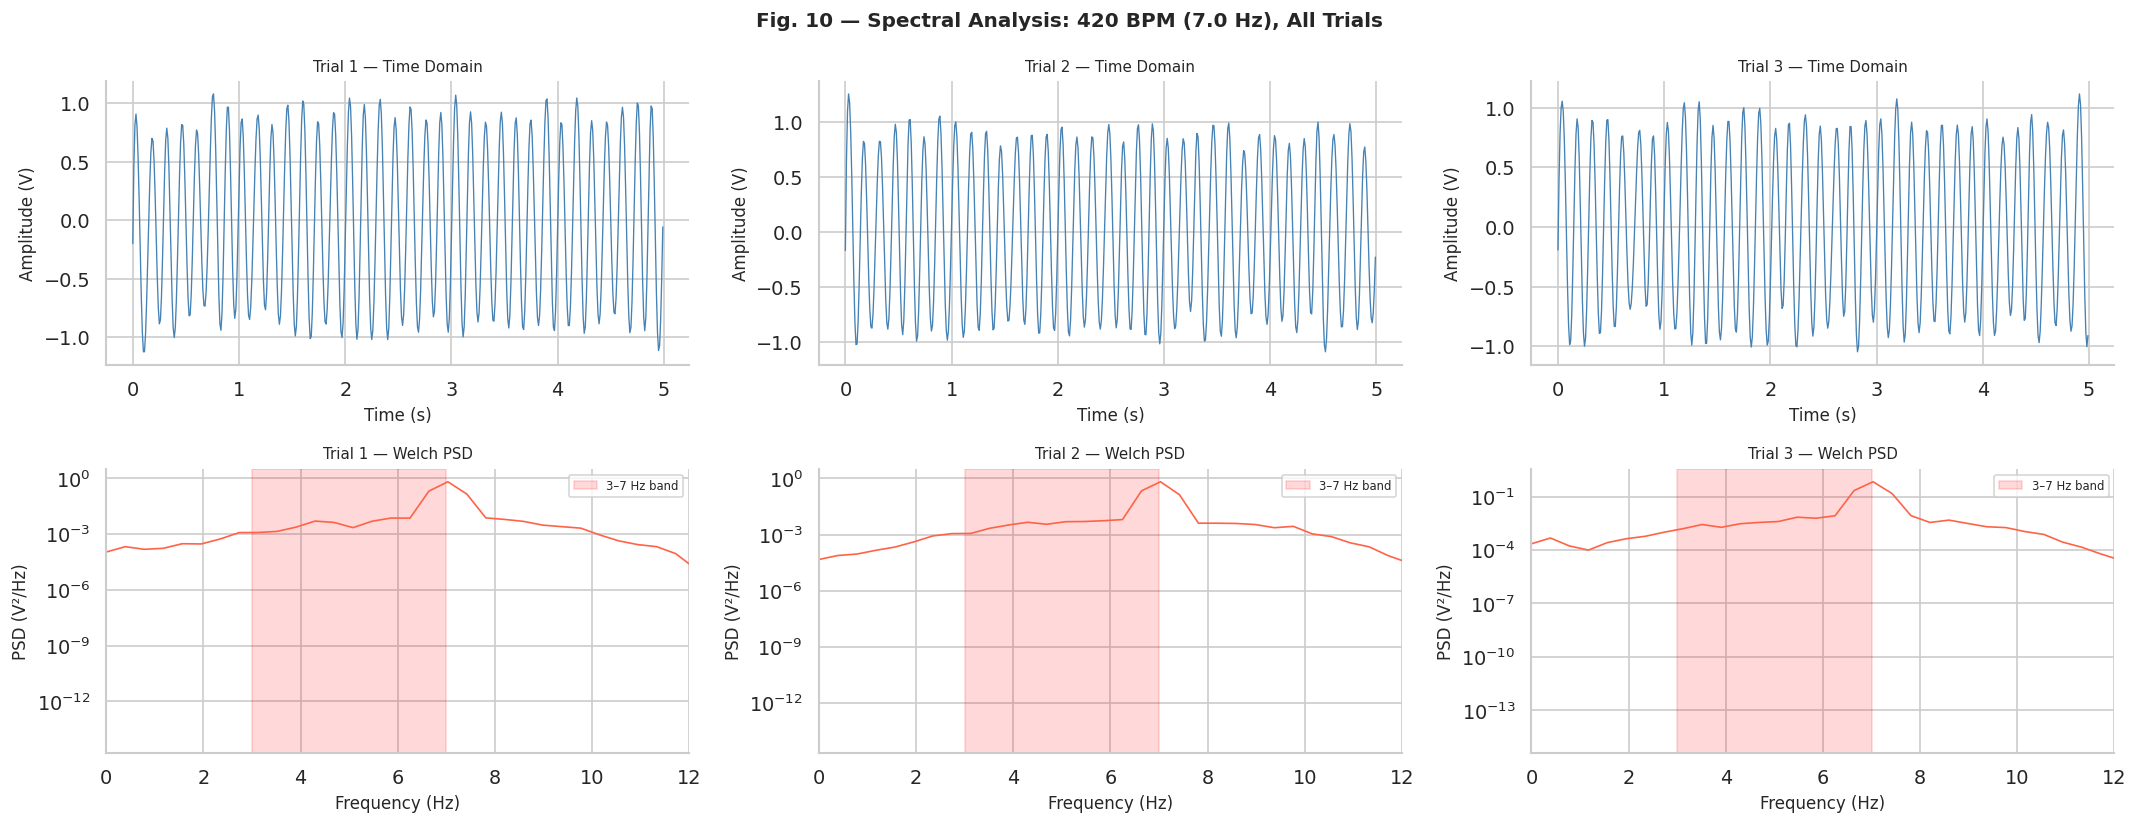

Spectral analysis figure saved for 420 BPM.


In [61]:
for bpm in bpm_list:

    # sorting trials according to set index
    recs = sorted(
        bpm_groups[bpm],
        key=lambda x: x['set_idx']
    )

    # creating subplot layout
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18, 7)
    )

    # Plotting All 3 Trials


    for col_i, r in enumerate(recs):

        # processed signal
        sig = r['signal_proc']

        # time axis
        t = np.arange(len(sig)) / FS

        # Top Row : Time-Domain Signal


        axes[0, col_i].plot(
            t[:int(5 * FS)],
            sig[:int(5 * FS)],

            color='steelblue',
            lw=0.8
        )

        axes[0, col_i].set_title(
            f'Trial {r["set_idx"]} — Time Domain',
            fontsize=9
        )

        axes[0, col_i].set_xlabel('Time (s)')

        axes[0, col_i].set_ylabel('Amplitude (V)')


        # Bottom Row : Welch PSD


        fw, psd_r = welch(
            sig,
            fs=FS,
            nperseg=256
        )

        axes[1, col_i].semilogy(
            fw,
            psd_r,

            color='tomato',
            lw=1.0
        )

        # highlighting tremor band
        axes[1, col_i].axvspan(
            3,
            7,

            alpha=0.15,
            color='red',

            label='3–7 Hz band'
        )

        axes[1, col_i].set_xlim(0, 12)

        axes[1, col_i].set_title(
            f'Trial {r["set_idx"]} — Welch PSD',
            fontsize=9
        )

        axes[1, col_i].set_xlabel('Frequency (Hz)')

        axes[1, col_i].set_ylabel('PSD (V²/Hz)')

        axes[1, col_i].legend(fontsize=7)

    # Main Figure Title


    fig.suptitle(
        f'Fig. 10 — Spectral Analysis: '
        f'{bpm} BPM ({bpm/60:.1f} Hz), All Trials',

        fontsize=12,
        fontweight='bold'
    )

    # adjusting spacing
    plt.tight_layout()

    # saving figure
    plt.savefig(
        f'fig10_spectral_{bpm}bpm.png',
        dpi=150,
        bbox_inches='tight'
    )

    # displaying figure
    plt.show()

    print(
        f"Spectral analysis figure saved for {bpm} BPM."
    )

15.Error calculation

In [62]:

# Fundamental Frequency Detection Error Analysis


# table header
print(
    f"{'BPM':<8}"
    f"{'Trial':<8}"
    f"{'Expected (Hz)':<16}"
    f"{'Detected (Hz)':<16}"
    f"{'Error (%)'}"
)

print("-" * 56)

# Frequency Detection for All Signals

err_records = []

for r in records:

    # detected dominant frequency
    detected = find_fundamental(
        r['signal_proc'],
        FS,
        r['freq_hz']
    )

    # percentage error calculation
    error = (
        abs(detected - r['freq_hz'])
        / r['freq_hz']
    ) * 100

    # storing results
    err_records.append({

        'bpm'         : r['bpm'],
        'set_idx'     : r['set_idx'],

        'expected_hz' : r['freq_hz'],
        'detected_hz' : detected,

        'error_pct'   : error
    })

    # printing row values
    print(
        f"{r['bpm']:<8}"
        f"{r['set_idx']:<8}"
        f"{r['freq_hz']:<16.3f}"
        f"{detected:<16.4f}"
        f"{error:.4f}"
    )


# Creating Error DataFrame


err_df = pd.DataFrame(
    err_records
)


# BPM-Wise Error Summary


avg_err = (
    err_df
    .groupby('bpm')
    .agg(

        freq_hz = (
            'expected_hz',
            'first'
        ),

        mean_detected = (
            'detected_hz',
            'mean'
        ),

        std_detected = (
            'detected_hz',
            'std'
        ),

        mean_error = (
            'error_pct',
            'mean'
        )
    )
    .reset_index()
)


# Overall Error Statistics

print("\nError Summary across all 21 signals:")

print(
    f"  Mean Error : "
    f"{err_df['error_pct'].mean():.4f} %"
)

print(
    f"  Std Error  : "
    f"{err_df['error_pct'].std():.4f} %"
)

print(
    f"  Min Error  : "
    f"{err_df['error_pct'].min():.4f} %"
)

print(
    f"  Max Error  : "
    f"{err_df['error_pct'].max():.4f} %"
)

BPM     Trial   Expected (Hz)   Detected (Hz)   Error (%)
--------------------------------------------------------
60      1       1.000           1.0712          7.1237
60      2       1.000           1.0799          7.9914
60      3       1.000           1.0864          8.6366
120     1       2.000           2.2485          12.4227
120     2       2.000           2.2173          10.8647
120     3       2.000           2.2173          10.8647
180     1       3.000           3.1529          5.0972
180     2       3.000           3.1234          4.1124
180     3       3.000           3.1596          5.3186
240     1       4.000           4.0181          0.4520
240     2       4.000           4.0040          0.1001
240     3       4.000           4.0161          0.4016
300     1       5.000           5.0000          0.0000
300     2       5.000           5.0075          0.1502
300     3       5.000           5.0000          0.0000
360     1       6.000           5.9970          0.0500
36